In [1]:
import pandas as pd
import numpy as np
import pygeohash as pgh
import matplotlib.pyplot as plt
import geohash2
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(77299, 11)
(41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
train_df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature',
       'Weather'],
      dtype='str')

In [4]:
for col in train_df.columns:
    # print(col)
    # print(train_df[col].unique()[:5])
    print(col,": ",train_df[col].dtype)

Index :  int64
geohash :  str
day :  int64
timestamp :  str
demand :  float64
RoadType :  str
NumberofLanes :  int64
LargeVehicles :  str
Landmarks :  str
Temperature :  float64
Weather :  str


# Data cleaning

In [5]:
def convert_string_columns_to_lowercase(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert all string/object columns to lowercase.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe

    Returns
    -------
    pd.DataFrame
        Dataframe with lowercase string values
    """
    df = df.copy()

    str_cols = df.select_dtypes(include=["object"]).columns

    for col in str_cols:
        df[col] = df[col].astype(str).str.lower()

    return df


def fill_categorical_missing_values(
    df: pd.DataFrame,
    categorical_cols: list
) -> pd.DataFrame:
    """
    Replace NaN and 'nan' strings in categorical columns
    with the most frequent value (mode).

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe
    categorical_cols : list
        List of categorical columns

    Returns
    -------
    pd.DataFrame
        Updated dataframe
    """
    df = df.copy()

    for col in categorical_cols:

        # Convert string 'nan' back to actual NaN
        df[col] = df[col].replace("nan", np.nan)

        # Most frequent value
        mode_value = df[col].mode()[0]

        # Fill missing values
        df[col] = df[col].fillna(mode_value)

    return df


def fill_temperature_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace missing Temperature values with mean temperature.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()

    mean_temp = df["Temperature"].mean()

    df["Temperature"] = df["Temperature"].fillna(mean_temp)

    return df


def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Complete data cleaning pipeline.

    Steps:
    1. Convert all strings to lowercase
    2. Fill missing RoadType with mode
    3. Fill missing Weather with mode
    4. Fill missing Temperature with mean

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
    """
    df = convert_string_columns_to_lowercase(df)

    df = fill_categorical_missing_values(
        df,
        categorical_cols=["RoadType", "Weather"]
    )

    df = fill_temperature_missing_values(df)

    return df

In [6]:
train_df = clean_dataset(train_df)

print(train_df.isna().sum())

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64


/tmp/ipykernel_25431/2696931964.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=["object"]).columns


In [7]:
train_df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,residential,1,not allowed,no,16.405354,sunny
1,1,qp02zt,48,0:0,0.118507,residential,3,allowed,yes,31.104565,sunny
2,2,qp08bj,48,0:0,0.027132,residential,1,not allowed,no,25.919267,sunny
3,3,qp08gt,48,0:0,0.003272,residential,1,not allowed,no,16.405354,rainy
4,4,qp02zq,48,0:0,0.010819,residential,1,not allowed,no,10.803667,rainy


# Feature engineering

In [8]:
def add_lat_lon(df: pd.DataFrame) -> pd.DataFrame:
    """
    Decode geohash into latitude and longitude.
    """
    df = df.copy()

    decoded = df["geohash"].apply(geohash2.decode)

    df["lat"] = decoded.apply(lambda x: x[0])
    df["lon"] = decoded.apply(lambda x: x[1])

    return df


def add_hour_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract hour from timestamp column.

    Example:
    '13:45' -> 13
    """
    df = df.copy()

    df["hour"] = (
        df["timestamp"]
        .astype(str)
        .str.split(":")
        .str[0]
        .astype(int)
    )

    return df


def add_geo_hour_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create geohash-hour interaction feature.
    """
    df = df.copy()

    df["geo_hour"] = (
        df["geohash"].astype(str)
        + "_"
        + df["hour"].astype(str)
    )

    return df


def get_period(hour: int) -> str:
    """
    Map hour to time period.
    """

    if hour < 5:
        return "night"

    elif hour < 12:
        return "morning"

    elif hour < 17:
        return "afternoon"

    elif hour < 21:
        return "evening"

    else:
        return "late_night"


def add_period_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create period feature from hour.
    """
    df = df.copy()

    df["period"] = df["hour"].apply(get_period)

    return df


def add_geo_period_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create geohash-period interaction feature.
    """
    df = df.copy()

    df["geo_period"] = (
        df["geohash"].astype(str)
        + "_"
        + df["period"].astype(str)
    )

    return df


def add_roadtype_period_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create RoadType-period interaction feature.
    """
    df = df.copy()

    df["roadtype_period"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["period"].astype(str)
    )

    return df


In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Complete feature engineering pipeline.

    Features created:
    - lat
    - lon
    - hour
    - geo_hour
    - period
    - geo_period
    - roadtype_period
    """
    df = add_lat_lon(df)

    df = add_hour_feature(df)

    df = add_geo_hour_feature(df)

    df = add_period_feature(df)

    df = add_geo_period_feature(df)

    df = add_roadtype_period_feature(df)

    return df

In [10]:
train_df = engineer_features(train_df)

print(train_df.head())

   Index geohash  day timestamp    demand     RoadType  NumberofLanes  \
0      0  qp02z1   48       0:0  0.048804  residential              1   
1      1  qp02zt   48       0:0  0.118507  residential              3   
2      2  qp08bj   48       0:0  0.027132  residential              1   
3      3  qp08gt   48       0:0  0.003272  residential              1   
4      4  qp02zq   48       0:0  0.010819  residential              1   

  LargeVehicles Landmarks  Temperature Weather    lat   lon  hour  geo_hour  \
0   not allowed        no    16.405354   sunny  -5.48  90.7     0  qp02z1_0   
1       allowed       yes    31.104565   sunny  -5.46  90.7     0  qp02zt_0   
2   not allowed        no    25.919267   sunny  -5.46  90.7     0  qp08bj_0   
3   not allowed        no    16.405354   rainy  -5.46  90.9     0  qp08gt_0   
4   not allowed        no    10.803667   rainy  -5.46  90.7     0  qp02zq_0   

  period    geo_period    roadtype_period  
0  night  qp02z1_night  residential_night 

# Training

In [11]:
import os
import joblib
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [12]:
TARGET = "demand"

DROP_COLS = [
    "Index",
    "timestamp",
    TARGET
]

FEATURE_COLS = [
    c for c in train_df.columns
    if c not in DROP_COLS
]

CAT_COLS = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "geo_hour",
    "period",
    "geo_period",
    "roadtype_period"
]

# OOF Target Encoding

In [13]:
def create_oof_target_encoding(
    df,
    group_col,
    target_col,
    n_splits=5,
    random_state=42
):
    """
    Create out-of-fold target encoding.
    """

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    global_mean = df[target_col].mean()

    encoded = pd.Series(
        index=df.index,
        dtype=float
    )

    for train_idx, val_idx in kf.split(df):

        train_fold = df.iloc[train_idx]
        val_fold = df.iloc[val_idx]

        mapping = (
            train_fold
            .groupby(group_col)[target_col]
            .mean()
        )

        encoded.iloc[val_idx] = (
            val_fold[group_col]
            .map(mapping)
            .fillna(global_mean)
        )

    return encoded

In [16]:
# train_df["geo_hour_te"] = create_oof_target_encoding(
#     train_df,
#     group_col="geo_hour",
#     target_col="demand",
#     n_splits=5
# )

In [17]:
# FEATURE_COLS.append("geo_hour_te")

In [14]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_scores = []

best_cat_model = None
best_cat_rmse = np.inf

In [19]:
for fold, (train_idx, valid_idx) in enumerate(kf.split(train_df), 1):

    print(f"\nFold {fold}")

    train_fold = train_df.iloc[train_idx].copy()
    valid_fold = train_df.iloc[valid_idx].copy()

    X_train = train_fold[FEATURE_COLS]
    y_train = train_fold[TARGET]

    X_valid = valid_fold[FEATURE_COLS]
    y_valid = valid_fold[TARGET]

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=10,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=100
    )

    model.fit(
        X_train,
        y_train,
        cat_features=CAT_COLS,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    preds = model.predict(X_valid)

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            preds
        )
    )

    r2 = r2_score(
        y_valid,
        preds
    )

    cat_scores.append(rmse)

    print(f"Fold RMSE: {rmse:.6f}")
    print(f"Fold R²  : {r2:.6f}")

    if rmse < best_cat_rmse:
        best_cat_rmse = rmse
        best_cat_model = model


Fold 1
0:	learn: 0.1387417	test: 0.1386471	best: 0.1386471 (0)	total: 116ms	remaining: 9m 41s
100:	learn: 0.0423139	test: 0.0412368	best: 0.0412368 (100)	total: 3.65s	remaining: 2m 57s
200:	learn: 0.0364561	test: 0.0364825	best: 0.0364825 (200)	total: 7.28s	remaining: 2m 53s
300:	learn: 0.0340461	test: 0.0348463	best: 0.0348463 (300)	total: 11.1s	remaining: 2m 52s
400:	learn: 0.0322334	test: 0.0336780	best: 0.0336780 (400)	total: 14.6s	remaining: 2m 47s
500:	learn: 0.0308891	test: 0.0328824	best: 0.0328824 (500)	total: 18.7s	remaining: 2m 47s
600:	learn: 0.0299325	test: 0.0324678	best: 0.0324678 (600)	total: 22.6s	remaining: 2m 45s
700:	learn: 0.0291110	test: 0.0321240	best: 0.0321240 (700)	total: 26.5s	remaining: 2m 42s
800:	learn: 0.0284693	test: 0.0318912	best: 0.0318912 (800)	total: 30.4s	remaining: 2m 39s
900:	learn: 0.0278650	test: 0.0317345	best: 0.0317345 (900)	total: 34.3s	remaining: 2m 36s
1000:	learn: 0.0273088	test: 0.0315679	best: 0.0315670 (998)	total: 38.1s	remaining: 2

In [20]:
cat_cv_rmse = np.mean(cat_scores)

print("\nCatBoost Results")
print("-" * 30)
print("Fold Scores:", cat_scores)
print("Mean RMSE:", cat_cv_rmse)


CatBoost Results
------------------------------
Fold Scores: [np.float64(0.03081590907032986), np.float64(0.031216173874932293), np.float64(0.030543609834061677), np.float64(0.03170856422260003), np.float64(0.030523494085105983)]
Mean RMSE: 0.03096155021740597


In [21]:
joblib.dump(
    best_cat_model,
    "models/best_model2.pkl"
)

joblib.dump(
    best_cat_model,
    "models/best_catboost2.pkl"
)

['models/best_catboost2.pkl']

In [19]:
import joblib
import pandas as pd

# Load model
model = joblib.load("models/best_catboost2.pkl")

# Feature importance
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": model.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance)

            feature  importance
0          RoadType   27.225180
1           geohash   18.868518
2   roadtype_period   15.897646
3     NumberofLanes    8.297505
4              hour    6.877224
5        geo_period    4.360188
6     LargeVehicles    4.310692
7               lat    3.901231
8               lon    2.622934
9          geo_hour    2.045069
10           period    1.684902
11              day    1.362848
12      Temperature    1.120652
13          Weather    1.053962
14        Landmarks    0.371450


In [22]:
from sklearn.metrics import r2_score

# Training features
X_train_full = train_df[FEATURE_COLS]
y_train_full = train_df["demand"]

# Predictions on training data
train_preds = best_cat_model.predict(X_train_full)

# R² score
train_r2 = r2_score(y_train_full, train_preds)

print(f"Training R² Score: {train_r2:.6f}")

Training R² Score: 0.967621


In [23]:
test_df.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [28]:
def fit_geo_hour_te_mapping(
    train_df,
    target_col="demand"
):
    """
    Fit target encoding mapping on FULL training data.
    Used only for inference.
    """

    global_mean = train_df[target_col].mean()

    geo_hour_mapping = (
        train_df
        .groupby("geo_hour")[target_col]
        .mean()
        .to_dict()
    )

    return geo_hour_mapping, global_mean

In [29]:
geo_hour_mapping, global_mean = fit_geo_hour_te_mapping(
    train_df
)

In [30]:
def add_geo_hour_te_feature(
    df,
    geo_hour_mapping,
    global_mean
):
    """
    Add geo_hour target encoding.
    """

    df = df.copy()

    df["geo_hour_te"] = (
        df["geo_hour"]
        .map(geo_hour_mapping)
        .fillna(global_mean)
    )

    return df

In [31]:
def prepare_test_data(
    test_df,
    geo_hour_mapping,
    global_mean
):
    """
    Complete preprocessing pipeline
    for inference.
    """

    df = test_df.copy()

    # cleaning
    df = clean_dataset(df)

    # feature engineering
    df = engineer_features(df)

    # target encoding
    # df = add_geo_hour_te_feature(
    #     df,
    #     geo_hour_mapping,
    #     global_mean
    # )

    return df

In [32]:
test_processed = prepare_test_data(
    test_df,
    geo_hour_mapping,
    global_mean
)

/tmp/ipykernel_300328/2696931964.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=["object"]).columns


In [33]:
test_processed.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,hour,geo_hour,period,geo_period,roadtype_period
0,0,qp02z1,49,2:15,residential,1,not allowed,no,16.457339,sunny,-5.48,90.7,2,qp02z1_2,night,qp02z1_night,residential_night
1,1,qp02z9,49,2:15,residential,1,not allowed,no,6.476213,snowy,-5.48,90.7,2,qp02z9_2,night,qp02z9_night,residential_night
2,2,qp02yf,49,2:15,residential,3,allowed,yes,22.318203,sunny,-5.48,90.7,2,qp02yf_2,night,qp02yf_night,residential_night
3,3,qp02z6,49,2:15,residential,2,not allowed,yes,16.457339,rainy,-5.48,90.7,2,qp02z6_2,night,qp02z6_night,residential_night
4,4,qp02zd,49,2:15,residential,1,not allowed,no,18.266162,foggy,-5.48,90.7,2,qp02zd_2,night,qp02zd_night,residential_night


In [34]:
X_test = test_processed[FEATURE_COLS]

test_preds = best_cat_model.predict(X_test)

In [35]:
submission = pd.DataFrame({
    "Index": test_df["Index"],
    "demand": test_preds
})

In [36]:
import os

os.makedirs(
    "../data/submissions",
    exist_ok=True
)

submission.to_csv(
    "../data/submissions/submission_3rdjune2.csv",
    index=False
)

print(submission.head())

   Index    demand
0      0  0.058333
1      1  0.023321
2      2  0.016303
3      3  0.024578
4      4  0.060753


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

test_plot_df = test_processed.copy()
test_plot_df["predicted_demand"] = test_preds

train_hourly = (
    train_df
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)
test_hourly = (
    test_plot_df
    .groupby("hour")["predicted_demand"]
    .mean()
    .reset_index()
)


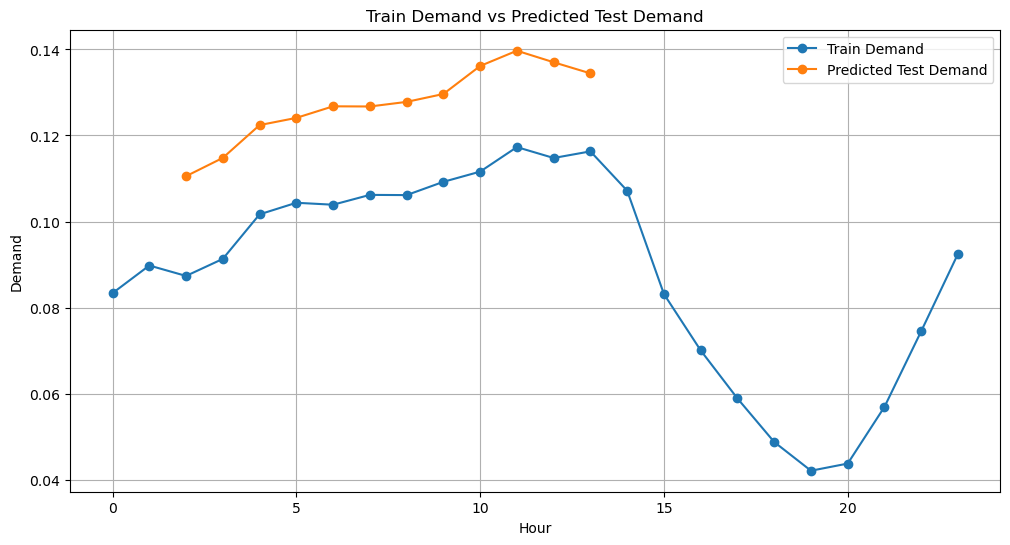

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    train_hourly["hour"],
    train_hourly["demand"],
    marker="o",
    label="Train Demand"
)

plt.plot(
    test_hourly["hour"],
    test_hourly["predicted_demand"],
    marker="o",
    label="Predicted Test Demand"
)

plt.xlabel("Hour")
plt.ylabel("Demand")
plt.title("Train Demand vs Predicted Test Demand")
plt.legend()
plt.grid(True)

plt.show()

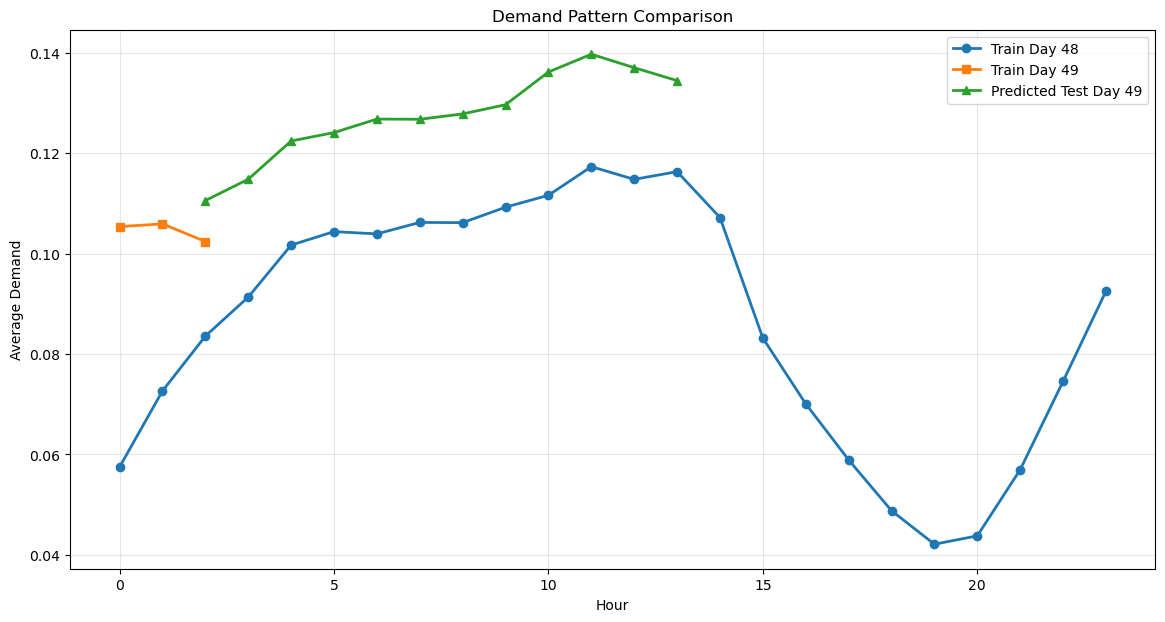

In [39]:
import matplotlib.pyplot as plt

# Day 48
day48_hourly = (
    train_df[train_df["day"] == 48]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

# Day 49
day49_hourly = (
    train_df[train_df["day"] == 49]
    .groupby("hour")["demand"]
    .mean()
    .reset_index()
)

# Test predictions
test_plot_df = test_processed.copy()
test_plot_df["predicted_demand"] = test_preds

test_hourly = (
    test_plot_df
    .groupby("hour")["predicted_demand"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(14, 7))

plt.plot(
    day48_hourly["hour"],
    day48_hourly["demand"],
    marker="o",
    linewidth=2,
    label="Train Day 48"
)

plt.plot(
    day49_hourly["hour"],
    day49_hourly["demand"],
    marker="s",
    linewidth=2,
    label="Train Day 49"
)

plt.plot(
    test_hourly["hour"],
    test_hourly["predicted_demand"],
    marker="^",
    linewidth=2,
    label="Predicted Test Day 49"
)

plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.title("Demand Pattern Comparison")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [42]:
top_geohashes = (
    train_df["geohash"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

print(top_geohashes)

['qp094q', 'qp03pr', 'qp094r', 'qp03r0', 'qp03r2', 'qp03q9', 'qp03r1', 'qp03r3', 'qp03r9', 'qp03qd']


In [44]:
import os
import matplotlib.pyplot as plt

# Create output folder
output_dir = "plots/geohash_demand_comparison"
os.makedirs(output_dir, exist_ok=True)

# Add predictions
test_plot_df = test_processed.copy()
test_plot_df["predicted_demand"] = test_preds

for geo in top_geohashes:

    plt.figure(figsize=(12, 6))

    # Day 48 Actual
    day48_curve = (
        train_df[
            (train_df["geohash"] == geo) &
            (train_df["day"] == 48)
        ]
        .groupby("hour")["demand"]
        .mean()
        .reset_index()
    )

    # Day 49 Actual
    day49_curve = (
        train_df[
            (train_df["geohash"] == geo) &
            (train_df["day"] == 49)
        ]
        .groupby("hour")["demand"]
        .mean()
        .reset_index()
    )

    # Test Predictions
    test_curve = (
        test_plot_df[
            test_plot_df["geohash"] == geo
        ]
        .groupby("hour")["predicted_demand"]
        .mean()
        .reset_index()
    )

    plt.plot(
        day48_curve["hour"],
        day48_curve["demand"],
        marker="o",
        linewidth=2,
        label="Day 48 Actual"
    )

    plt.plot(
        day49_curve["hour"],
        day49_curve["demand"],
        marker="s",
        linewidth=2,
        label="Day 49 Actual"
    )

    plt.plot(
        test_curve["hour"],
        test_curve["predicted_demand"],
        marker="^",
        linewidth=2,
        label="Test Predicted"
    )

    plt.title(f"Demand Pattern for Geohash: {geo}")
    plt.xlabel("Hour")
    plt.ylabel("Demand")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Save plot
    save_path = os.path.join(
        output_dir,
        f"{geo}_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {save_path}")

Saved: plots/geohash_demand_comparison/qp094q_comparison.png
Saved: plots/geohash_demand_comparison/qp03pr_comparison.png
Saved: plots/geohash_demand_comparison/qp094r_comparison.png
Saved: plots/geohash_demand_comparison/qp03r0_comparison.png
Saved: plots/geohash_demand_comparison/qp03r2_comparison.png
Saved: plots/geohash_demand_comparison/qp03q9_comparison.png
Saved: plots/geohash_demand_comparison/qp03r1_comparison.png
Saved: plots/geohash_demand_comparison/qp03r3_comparison.png
Saved: plots/geohash_demand_comparison/qp03r9_comparison.png
Saved: plots/geohash_demand_comparison/qp03qd_comparison.png
